# Figure 3 — Foundation validation: masked-band reconstruction

Three **held-out** tiles (validation split, unseen in training), one representative band each:
Rubin r, Euclid VIS, Euclid NISP H. For each, the band is withheld and reconstructed from the
other nine (the pre-training objective). Columns: truth / model / residual on a diverging scale
set to the source peak; per-panel bright-pixel correlation r.

**Interactive tile picking:**
1. Run the **Setup** cell once — it loads the model + dataset (~1–2 min) and prints the list of
   held-out tile indices you can choose from. Leave the kernel running.
2. In the **Pick tiles & preview** cell, put a held-out index for each row, run it — the figure
   shows inline in seconds (model stays loaded). Try as many as you like.
3. When happy, set `SAVE = True` and re-run that cell to write `paper/figures/fig3_reconstruction.png`.

**Quantitative cells** (both cached to pkl in this directory; delete the pkl to recompute):
4. **Per-band fidelity sweep** — bright-pixel Pearson r for every band × all 39 held-out tiles;
   source of the per-band numbers quoted in the caption and Sec. 4.
5. **Linear baseline** — referee stress test: can a linear combination of the other nine bands
   (per-pixel, and a 7×7 linear conv "PSF-matching" variant, both fit directly on the scored
   pixels) match the model's bright-pixel r? Quantifies what part of reconstruction fidelity
   is a mere color transform vs. genuine nonlinear/resolution transfer.

Pure inference on `models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt` (Euclid Q1; Rubin DP1).

In [1]:
# ============================== SETUP (run once) ==============================
# Loads the foundation model + dataset into memory and defines reconstruct().
# Re-run only if you change CKPT (or restart the kernel).
import sys, numpy as np, torch
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(parents=True, exist_ok=True)
# Q1 foundation (trained on Euclid Q1 MER mosaics); Rubin DP1 unchanged.
CKPT = REPO / 'models' / 'checkpoints' / 'jaisp_v10_q1_long' / 'checkpoint_best.pt'

if 'MODEL' not in globals():
    sys.path.insert(0, str(REPO / 'models'))
    from load_foundation import load_foundation
    from jaisp_dataset_v10 import JAISPDatasetV10
    DEV = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    _ck = torch.load(str(CKPT), map_location='cpu', weights_only=False)
    VAL_IDX = sorted(int(x) for x in _ck['val_indices'])
    MODEL = load_foundation(str(CKPT), device=DEV, freeze=True)
    DS = JAISPDatasetV10(rubin_dir=str(REPO / 'data' / 'rubin_tiles_all'),
                         euclid_dir=str(REPO / 'data' / 'euclid_tiles_all_q1'),
                         load_euclid=True, augment=False)
    print(f'\nLoaded. {len(VAL_IDX)} HELD-OUT tiles to choose from (pick indices from this list):')
    print(VAL_IDX)
else:
    print('MODEL & DS already loaded. (To reload after changing CKPT: restart kernel, or run '
          "`del MODEL` then re-run this cell.)")
    print(f'{len(VAL_IDX)} held-out tiles:', VAL_IDX)

def reconstruct(idx, band, ps, fov):
    """Withhold `band` from held-out tile `idx`, reconstruct from the other 9,
    return dict(truth, pred, resid, r) cropped to `fov` arcsec."""
    assert idx in VAL_IDX, (f'tile {idx} is NOT held out (not in the val split) — '
                            f'pick an index from the printed list.')
    s = DS[idx]; pool = {}; pool.update(s['rubin']); pool.update(s.get('euclid', {}))
    assert band in pool, f'band {band} not present in tile {idx}'
    ctx = [x for x in pool if x != band]
    ci = {x: pool[x]['image'].unsqueeze(0).to(DEV) for x in ctx}
    cr = {x: pool[x]['rms'].unsqueeze(0).to(DEV) for x in ctx}
    ti = pool[band]['image'].unsqueeze(0).to(DEV); tr = pool[band]['rms'].unsqueeze(0).to(DEV)
    with torch.no_grad():
        out = MODEL(ci, cr, band, ti, tr)
    truth = out['target_norm'][0, 0].cpu().numpy(); pred = out['pred'][0, 0].cpu().numpy()
    info = out['info_weights'][0, 0].cpu().numpy(); m = info >= np.nanpercentile(info, 90)
    r = float(np.corrcoef(truth[m], pred[m])[0, 1])
    h = int(round(fov / ps / 2)); c0, c1 = truth.shape[0] // 2, truth.shape[1] // 2
    sl = (slice(c0 - h, c0 + h), slice(c1 - h, c1 + h))
    return dict(idx=idx, band=band, tile=DS.tiles[idx]['tile_id'],
                truth=truth[sl], pred=pred[sl], resid=truth[sl] - pred[sl], r=r)

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt
JAISPDatasetV10: scanning 790 tiles...


  790 tiles passed quality cuts
  790 tiles have Euclid coverage

Loaded. 39 HELD-OUT tiles to choose from (pick indices from this list):
[23, 39, 67, 97, 137, 168, 174, 199, 211, 215, 218, 235, 247, 300, 352, 356, 361, 367, 380, 394, 433, 446, 467, 478, 479, 511, 519, 534, 544, 548, 568, 588, 602, 616, 692, 695, 727, 776, 786]


rubin_r     tile 23 (tile_x00000_y01024_tract5063_patch_4)  r=0.998
euclid_VIS  tile 616 (tile_x02048_y02304_tract5063_patch_5)  r=0.867
euclid_H    tile 511 (tile_x01792_y01024_tract5063_patch_24)  r=0.927


SAVED -> /home/shemmati/Work/Projects/JAISP/paper/figures/fig3_reconstruction.png


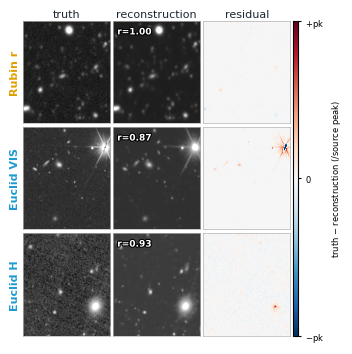

In [2]:
# ========================= PICK TILES & PREVIEW =========================
# Put a HELD-OUT tile index for each row (see the list printed by Setup),
# run this cell to preview inline. Set SAVE=True to write the paper PNG.
RUBIN_R_TILE    = 23    # Rubin r   row
EUCLID_VIS_TILE = 616    # Euclid VIS row
EUCLID_H_TILE   = 511    # Euclid H  row
FOV  = 48.0              # arcsec central crop
SAVE = True            # False = preview only; True = overwrite paper/figures/fig3_reconstruction.png
# ========================================================================

ROWS = [(RUBIN_R_TILE, 'rubin_r', 0.2), (EUCLID_VIS_TILE, 'euclid_VIS', 0.1), (EUCLID_H_TILE, 'euclid_H', 0.1)]
rows = [reconstruct(idx, band, ps, FOV) for idx, band, ps in ROWS]
for d in rows:
    print(f"{d['band']:11s} tile {d['idx']} ({d['tile']})  r={d['r']:.3f}")

C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'
BANDLAB = {'rubin_r': ('Rubin r', C_RUBIN), 'euclid_VIS': ('Euclid VIS', C_EUCLID),
           'euclid_H': ('Euclid H', C_EUCLID)}

# Single-column (AAS) geometry: build at ~column width so fonts render true-size.
fig = plt.figure(figsize=(3.5, 3.55))
gs = GridSpec(3, 4, figure=fig, width_ratios=[1, 1, 1, 0.05], wspace=0.04, hspace=0.04,
              left=0.115, right=0.90, top=0.90, bottom=0.015)
colhead = ['truth', 'reconstruction', 'residual']
im_res = None
for i, d in enumerate(rows):
    nrm = ImageNormalize(d['truth'], interval=PercentileInterval(99.5), stretch=AsinhStretch(0.1))
    V = float(np.nanpercentile(d['truth'], 99.5))   # bright scale; residual shown on +/- V
    name, col = BANDLAB[d['band']]
    for j, key in enumerate(['truth', 'pred', 'resid']):
        ax = fig.add_subplot(gs[i, j])
        if key == 'resid':
            im_res = ax.imshow(d['resid'], origin='lower', cmap='RdBu_r', vmin=-V, vmax=V, aspect='auto')
        else:
            ax.imshow(d[key], origin='lower', cmap='gray', norm=nrm, aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_edgecolor('0.7'); s.set_linewidth(0.5)
        if i == 0:
            ax.set_title(colhead[j], fontsize=8, color=INK, pad=3)
        if j == 0:
            ax.set_ylabel(name, fontsize=8, color=col, weight='bold', labelpad=2)
        if j == 1:
            ax.text(0.05, 0.94, f"r={d['r']:.2f}", transform=ax.transAxes, ha='left', va='top',
                    fontsize=6.5, color='white', weight='bold',
                    path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])
# shared residual colorbar. The residual is signed (truth - model): red = model under-predicted,
# blue = over-predicted. Each row's residual is scaled to ITS OWN source peak, so the endpoints
# are labelled conceptually (-peak / 0 / +peak): a residual reaches full color only if an error
# is as large as the brightest source pixel. Near-white => faithful reconstruction.
cax = fig.add_subplot(gs[:, 3])
cb = fig.colorbar(im_res, cax=cax)
cb.set_ticks([-V, 0, V])
cb.set_ticklabels([r'$-$pk', '0', r'$+$pk'])
cb.set_label('truth $-$ reconstruction (/source peak)', fontsize=6)
cb.ax.tick_params(labelsize=6, length=2)

if SAVE:
    out = FIGDIR / 'fig3_reconstruction.png'
    fig.savefig(out, dpi=400, bbox_inches='tight', facecolor='white')
    print('SAVED ->', out)
else:
    print('preview only (SAVE=False) — set SAVE=True and re-run to write the paper PNG')
plt.show()

loaded cache _fig3_band_r_cache_q1_long.pkl

band         mean r  median    min    max   n
rubin_u       0.653   0.730  0.150  0.967  39
rubin_g       0.989   0.993  0.951  0.997  39
rubin_r       0.993   0.996  0.972  0.998  39
rubin_i       0.989   0.996  0.942  0.998  39
rubin_z       0.975   0.988  0.868  0.998  39
rubin_y       0.854   0.934  0.324  0.979  39
euclid_VIS    0.774   0.816  0.549  0.913  39
euclid_Y      0.849   0.849  0.634  0.952  39
euclid_J      0.877   0.878  0.682  0.951  39
euclid_H      0.896   0.903  0.693  0.960  39


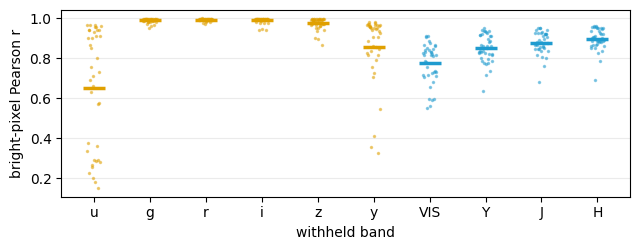

In [3]:
# ============ PER-BAND FIDELITY OVER ALL HELD-OUT TILES ============
# For every held-out tile, withhold each band in turn and record the same
# bright-pixel Pearson r the figure annotates (top 10% info-weighted pixels,
# full tile). Cached — delete the pkl to recompute (~15 min on GPU).
# These are the per-band numbers quoted in the caption and Sec. 4.
import pickle
CACHE = Path('_fig3_band_r_cache_q1_long.pkl')
if CACHE.exists():
    PER_TILE_R = pickle.load(open(CACHE, 'rb'))
    print(f'loaded cache {CACHE}')
else:
    PER_TILE_R = {}   # band -> list of (tile_idx, r)
    for n, idx in enumerate(VAL_IDX):
        s = DS[idx]; pool = {}; pool.update(s['rubin']); pool.update(s.get('euclid', {}))
        for band in pool:
            ctx = [x for x in pool if x != band]
            ci = {x: pool[x]['image'].unsqueeze(0).to(DEV) for x in ctx}
            cr = {x: pool[x]['rms'].unsqueeze(0).to(DEV) for x in ctx}
            ti = pool[band]['image'].unsqueeze(0).to(DEV); tr = pool[band]['rms'].unsqueeze(0).to(DEV)
            with torch.no_grad():
                out = MODEL(ci, cr, band, ti, tr)
            truth = out['target_norm'][0, 0].cpu().numpy(); pred = out['pred'][0, 0].cpu().numpy()
            info = out['info_weights'][0, 0].cpu().numpy(); m = info >= np.nanpercentile(info, 90)
            PER_TILE_R.setdefault(band, []).append((idx, float(np.corrcoef(truth[m], pred[m])[0, 1])))
        print(f'{n+1}/{len(VAL_IDX)} tiles', end='\r')
    pickle.dump(PER_TILE_R, open(CACHE, 'wb'))
    print(f'\nsaved cache -> {CACHE}')

ORDER = ['rubin_u', 'rubin_g', 'rubin_r', 'rubin_i', 'rubin_z', 'rubin_y',
         'euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']
ORDER = [b for b in ORDER if b in PER_TILE_R]
print(f'\n{"band":11s} {"mean r":>7s} {"median":>7s} {"min":>6s} {"max":>6s} {"n":>3s}')
for b in ORDER:
    rs = np.array([r for _, r in PER_TILE_R[b]])
    print(f'{b:11s} {rs.mean():7.3f} {np.median(rs):7.3f} {rs.min():6.3f} {rs.max():6.3f} {len(rs):3d}')

# strip plot: per-tile r with the mean marked, Rubin gold / Euclid blue
fig, ax = plt.subplots(figsize=(6.5, 2.6))
for k, b in enumerate(ORDER):
    rs = np.array([r for _, r in PER_TILE_R[b]])
    col = '#e0a000' if b.startswith('rubin') else '#1f9bcf'
    ax.plot(np.full_like(rs, k) + np.linspace(-0.12, 0.12, len(rs)), rs, '.', ms=3, color=col, alpha=0.45)
    ax.plot(k, rs.mean(), '_', ms=16, mew=2.5, color=col)
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([b.split('_')[1] for b in ORDER])
ax.set_ylabel('bright-pixel Pearson r')
ax.set_xlabel('withheld band')
ax.grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

39/39 tiles
band          model  lin-pix  lin-conv   (mean bright-pixel r, 39 held-out tiles)
rubin_u       0.653    0.567     0.619
rubin_g       0.989    0.968     0.982
rubin_r       0.993    0.987     0.992
rubin_i       0.989    0.982     0.988
rubin_z       0.975    0.954     0.969
rubin_y       0.854    0.776     0.824
euclid_VIS    0.774    0.745     0.764
euclid_Y      0.849    0.823     0.851
euclid_J      0.877    0.849     0.878
euclid_H      0.896    0.857     0.893


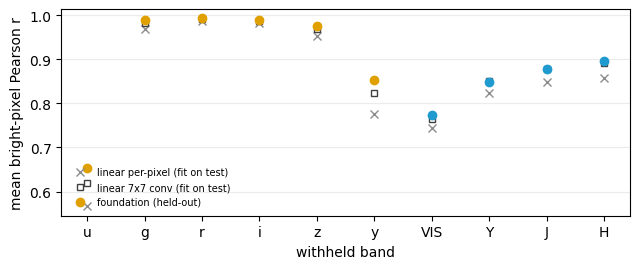

In [4]:
# ============ LINEAR BASELINE: CAN SIMPLE INTERPOLATION MATCH THIS? ============
# Referee stress test: predict each withheld band as a LINEAR function of the
# other nine and score it with the identical bright-pixel Pearson r as above.
# Two baselines, both fit ON THE VERY PIXELS THEY ARE SCORED ON (in-tile,
# in-mask fit = an upper bound that no honest global linear scheme can beat):
#   A. per-pixel:    target = a0 + sum_b a_b * band_b              (10 params)
#   B. conv-kernel:  target = a0 + sum_b (K_b * band_b), 7x7 K_b  (442 params)
# B is "linear interpolation + PSF matching": it can shift/smooth/sharpen each
# band linearly, but cannot invent spatial frequencies or adapt per source.
# Inputs are noise-normalised and clamped exactly as the network sees them;
# truth and mask reuse the model's own deterministic definitions
# (target_norm = clamp(img/rms), mask = top-10% InformationMap weights).
import pickle, torch.nn.functional as F

K = 7
CACHE_LIN = Path('_fig3_linear_baseline_cache.pkl')
LIN = pickle.load(open(CACHE_LIN, 'rb')) if CACHE_LIN.exists() else {}  # band -> {tile_idx: (rA, rB)}

def _ridge_r(X, y):
    """Ridge fit (tiny relative penalty) and Pearson r of the fit, same pixels."""
    X = torch.cat([X, torch.ones_like(X[:, :1])], 1).double()
    y = y.double()
    XtX = X.T @ X
    XtX += 1e-8 * torch.trace(XtX) / X.shape[1] * torch.eye(X.shape[1], device=X.device, dtype=X.dtype)
    beta = torch.linalg.solve(XtX, X.T @ y)
    p = X @ beta
    return float(torch.corrcoef(torch.stack([p, y]))[0, 1])

for n, idx in enumerate(VAL_IDX):
    if all(idx in LIN.get(b, {}) for b in ORDER):
        continue
    s = DS[idx]; pool = {}; pool.update(s['rubin']); pool.update(s.get('euclid', {}))
    norm = {b: (pool[b]['image'] / (pool[b]['rms'] + 1e-10)).clamp(-10.0, 100.0).to(DEV) for b in pool}
    for band in pool:
        if idx in LIN.get(band, {}):
            continue
        ti = pool[band]['image'].unsqueeze(0).to(DEV); tr = pool[band]['rms'].unsqueeze(0).to(DEV)
        with torch.no_grad():
            info = MODEL.encoder.info_maps[band](ti, tr)[0, 0].cpu().numpy()
            m = torch.from_numpy(info >= np.nanpercentile(info, 90)).to(DEV)
            y_img = (ti / (tr + 1e-10)).clamp(-10.0, 100.0)[0, 0]
            Ht, Wt = y_img.shape
            ctx = torch.cat([F.interpolate(norm[b].unsqueeze(0), size=(Ht, Wt), mode='bilinear',
                                           align_corners=False, antialias=True)
                             for b in pool if b != band], dim=1)          # (1, 9, Ht, Wt)
            y = y_img[m]
            rA = _ridge_r(ctx[0].permute(1, 2, 0)[m], y)                  # (Nmask, 9)
            rB = _ridge_r(F.unfold(ctx, K, padding=K // 2)[0].T[m.flatten()], y)  # (Nmask, 9*K*K)
        LIN.setdefault(band, {})[idx] = (rA, rB)
    pickle.dump(LIN, open(CACHE_LIN, 'wb'))
    print(f'{n+1}/{len(VAL_IDX)} tiles', end='\r')

print(f'\n{"band":11s} {"model":>7s} {"lin-pix":>8s} {"lin-conv":>9s}   (mean bright-pixel r, {len(VAL_IDX)} held-out tiles)')
STATS = {}
for b in ORDER:
    rm = np.mean([r for _, r in PER_TILE_R[b]])
    ra = np.mean([v[0] for v in LIN[b].values()])
    rb = np.mean([v[1] for v in LIN[b].values()])
    STATS[b] = (rm, ra, rb)
    print(f'{b:11s} {rm:7.3f} {ra:8.3f} {rb:9.3f}')

fig, ax = plt.subplots(figsize=(6.5, 2.8))
xs = np.arange(len(ORDER))
ax.plot(xs, [STATS[b][1] for b in ORDER], 'x', ms=6, color='0.55', label='linear per-pixel (fit on test)')
ax.plot(xs, [STATS[b][2] for b in ORDER], 's', ms=5, mfc='none', color='0.25', label=f'linear {K}x{K} conv (fit on test)')
for k, b in enumerate(ORDER):
    col = '#e0a000' if b.startswith('rubin') else '#1f9bcf'
    ax.plot(k, STATS[b][0], 'o', ms=6, color=col)
ax.plot([], [], 'o', ms=6, color='#e0a000', label='foundation (held-out)')
ax.set_xticks(xs); ax.set_xticklabels([b.split('_')[1] for b in ORDER])
ax.set_ylabel('mean bright-pixel Pearson r'); ax.set_xlabel('withheld band')
ax.grid(alpha=0.25, axis='y'); ax.legend(fontsize=7, loc='lower left', frameon=False)
plt.tight_layout(); plt.show()